# 08 — Multi-Grating Nitrogen Abundances (Berg+25 method)

**Purpose:** Replicate the nitrogen abundance methodology of
[Berg et al. (2025)](https://arxiv.org/abs/2511.13591) for the lensed
galaxy RXCJ2248-ID3 (source 2478_3, z ~ 6.1) using three NIRSpec
medium-resolution grating spectra.

### Methodology (following Berg+25)

1. **Dust correction** from Hgamma/Hbeta Balmer decrement (Cardelli+89)
2. **Multi-phase electron density** from 5 diagnostics:
   - N IV] 1483/1487 -> n_e(N3+) -- high-ionisation UV
   - C III] 1907/1909 -> n_e(C2+) -- intermediate UV
   - Si III] 1883/1892 -> n_e(Si2+) -- intermediate UV
   - [Ar IV] 4713/4741 -> n_e(Ar3+) -- high-ionisation optical
   - [S II] 6718/6732 -> n_e(S+) -- low-ionisation optical
3. **Electron temperature** from [O III] 4363/5007 + Garnett (1992)
   Te-Te relations for 3 ionisation zones
4. **Ionic abundances** with zone-specific Te/ne
5. **Four N/O methods** (Berg+25 Eqs. 2-5):
   - Method 1: N+/O+
   - Method 2: N2+/O2+
   - Method 3: N3+/O2+
   - Method 4: (N+ + N2+ + N3+) / (O+ + O2+)

| Grating | Coverage (um) | N lines | Density diagnostics |
|---------|---------------|---------|---------------------|
| G140M   | 0.97-1.87     | NIV] 1483/1487, NIII] 1749/1752 | NIV], CIII], SiIII] |
| G235M   | 1.66-3.17     | --      | [OII] 3726/3729 |
| G395M   | 2.87-5.27     | [NII] 5756, 6549, 6585 | [ArIV], [SII] |

**Date:** 2026-02-19

In [1]:
import jwspecfit
from jwspecfit.lines import REST_LINES_A, observable_lines
from jwspecabund.dust import cardelli_extinction, compute_Av_from_balmer
from jwspecabund.forward import hbeta_emissivity_aller84
import matplotlib.pyplot as plt
import numpy as np
import pyneb as pn

z = 6.1052

print(f"jwspecfit  v{jwspecfit.__version__}")
print(f"pyneb     v{pn.__version__}")

jwspecfit  v0.1.0
pyneb     v1.1.28


## 1. Load the three grating spectra

In [2]:
spec_g140m = jwspecfit.read_fits(
    "../../data/stark-rxcj2248-v4_g140m-f100lp_2478_3.spec.fits", z=z,
)
spec_g235m = jwspecfit.read_fits(
    "../../data/stark-rxcj2248-v4_g235m-f170lp_2478_3.spec.fits", z=z,
)
spec_g395m = jwspecfit.read_fits(
    "../../data/stark-rxcj2248-v4_g395m-f290lp_2478_3.spec.fits", z=z,
)

for name, spec in [("G140M", spec_g140m), ("G235M", spec_g235m), ("G395M", spec_g395m)]:
    v = spec.mask_valid()
    print(f"{name}: {spec.n_pix} px, {spec.wave_um[v].min():.3f}-{spec.wave_um[v].max():.3f} um")

G140M: 4667 px, 0.957-2.734 um
G235M: 3685 px, 1.605-4.574 um
G395M: 1661 px, 2.685-5.500 um


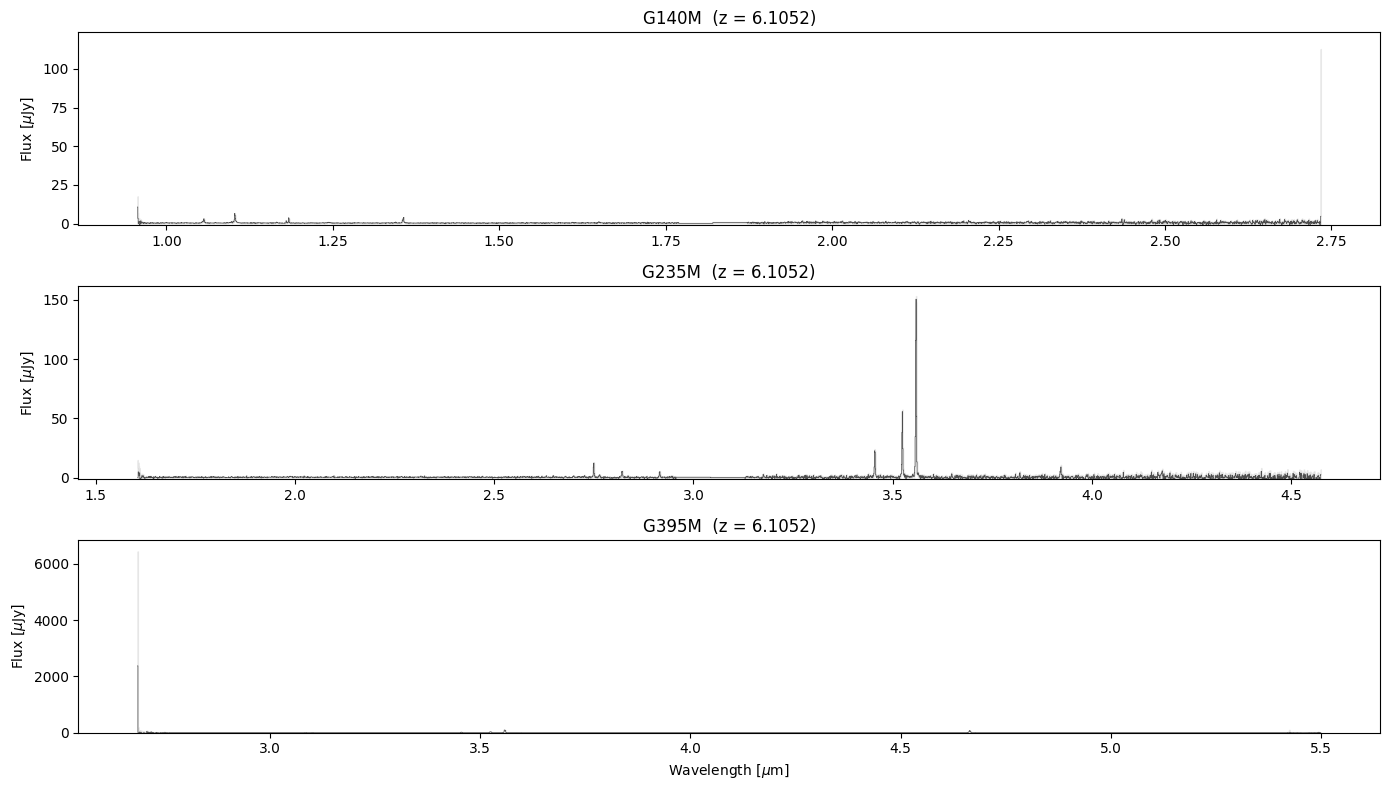

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)

for ax, (name, spec) in zip(axes, [("G140M", spec_g140m), ("G235M", spec_g235m), ("G395M", spec_g395m)]):
    v = spec.mask_valid()
    ax.step(spec.wave_um[v], spec.flux_ujy[v], where="mid", lw=0.5, color="0.3")
    ax.fill_between(
        spec.wave_um[v],
        (spec.flux_ujy - spec.err_ujy)[v],
        (spec.flux_ujy + spec.err_ujy)[v],
        step="mid", alpha=0.15, color="0.5",
    )
    ax.set_ylabel(r"Flux [$\mu$Jy]")
    ax.set_title(f"{name}  (z = {z})")
    ax.set_ylim(-1, None)

axes[-1].set_xlabel(r"Wavelength [$\mu$m]")
plt.tight_layout()

## 2. Fit G395M -- optical lines

Expanded line list: add [Ar IV] 4713/4741 (density diagnostic),
He II 4687 (y2+), and He I 4472.

In [4]:
# Build expanded G395M line list
g395m_lines = jwspecfit.lines.get_line_list("g395m") + [
    "HeI_4472",
    "HeII_4687",
    "ArIV_4713",
    "ArIV_4741",
]

# Filter to observable range
v = spec_g395m.mask_valid()
g395m_lines = observable_lines(
    g395m_lines, z,
    spec_g395m.wave_um[v].min(), spec_g395m.wave_um[v].max(),
)

print("G395M lines to fit:")
for name in g395m_lines:
    obs_um = REST_LINES_A[name] * (1 + z) * 1e-4
    print(f"  {name:<16s}  rest {REST_LINES_A[name]:.1f} A  ->  obs {obs_um:.4f} um")

G395M lines to fit:
  HDELTA            rest 4104.0 A  ->  obs 2.9160 um
  HGAMMA            rest 4342.9 A  ->  obs 3.0857 um
  OIII_4363         rest 4364.4 A  ->  obs 3.1010 um
  HBETA             rest 4864.0 A  ->  obs 3.4560 um
  OIII_4959         rest 4961.7 A  ->  obs 3.5254 um
  OIII_5007         rest 5009.6 A  ->  obs 3.5594 um
  NII_5756          rest 5757.8 A  ->  obs 4.0910 um
  HEI_5877          rest 5878.9 A  ->  obs 4.1771 um
  NII_6549          rest 6551.7 A  ->  obs 4.6551 um
  Ha                rest 6566.4 A  ->  obs 4.6656 um
  NII_6585          rest 6587.1 A  ->  obs 4.6803 um
  SII_6718          rest 6720.1 A  ->  obs 4.7748 um
  SII_6732          rest 6734.5 A  ->  obs 4.7850 um
  HeI_4472          rest 4472.7 A  ->  obs 3.1780 um
  HeII_4687         rest 4687.0 A  ->  obs 3.3302 um
  ArIV_4713         rest 4712.6 A  ->  obs 3.3484 um
  ArIV_4741         rest 4741.5 A  ->  obs 3.3689 um


In [5]:
result_g395m = jwspecfit.fit_lines(spec_g395m, z=z, deg=3, n_boot=1000, lines=g395m_lines)

print(f"Lines fitted: {len(result_g395m.lines)}")
print(f"chi2/dof:     {result_g395m.chi2:.2f}")
print()
print(f"{'Line':<18s} {'Flux':>12s} {'Err':>12s} {'SNR':>8s}")
print("-" * 52)
for name, lr in result_g395m.lines.items():
    tag = " *" if "BROAD" in name else ""
    print(f"{name + tag:<18s} {lr.flux:12.3e} {lr.flux_err:12.3e} {lr.snr:8.1f}")

Bootstrap (broad1): 100%|██████████| 1000/1000 [01:15<00:00, 13.21iter/s]

Lines fitted: 21
chi2/dof:     1.08

Line                       Flux          Err      SNR
----------------------------------------------------
HDELTA                1.944e-18    8.287e-19      2.3
HGAMMA                6.245e-18    1.312e-18      4.8
OIII_4363             6.154e-18    1.102e-18      5.6
HBETA                 1.593e-17    1.368e-18     11.6
OIII_4959             3.000e-17    1.625e-18     18.5
OIII_5007             8.776e-17    1.731e-18     50.7
NII_5756              3.708e-19    2.865e-19      1.3
HEI_5877              2.831e-18    4.918e-19      5.8
NII_6549              4.062e-19    2.576e-20     15.8
Ha                    3.941e-17    1.392e-18     28.3
NII_6585              1.202e-18    7.625e-20     15.8
SII_6718              2.083e-19    3.036e-19      0.7
SII_6732              7.186e-29    1.759e-19      0.0
HeI_4472              9.114e-19    3.507e-19      2.6
HeII_4687             4.705e-19    3.309e-19      1.4
ArIV_4713             3.748e-19    2.706e-19  

/Users/raunaqrai/miniforge3/envs/jwst/lib/python3.12/site-packages/jwspecfit/plotting.py:284: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


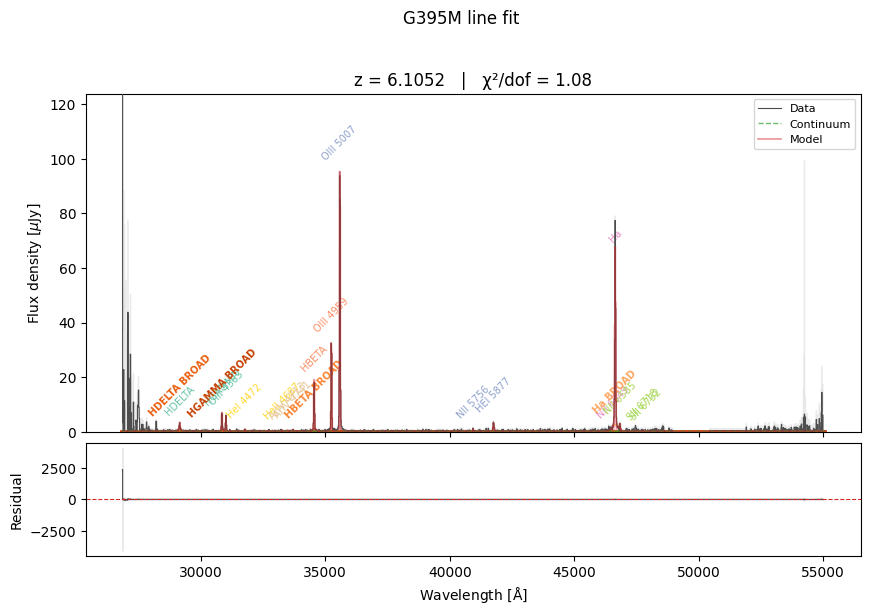

In [6]:
fig = jwspecfit.plot_fit(result_g395m)
fig.suptitle("G395M line fit", y=1.02)
plt.show()

## 3. Fit G235M -- [OII] doublet, [OIII] 4363

In [ ]:
# G235M: filter line list to valid wavelength range
v = spec_g235m.mask_valid()
g235m_lines = observable_lines(
    jwspecfit.lines.get_line_list("g235m"), z,
    spec_g235m.wave_um[v].min(), spec_g235m.wave_um[v].max(),
)

print("G235M lines to fit:")
for name in g235m_lines:
    obs_um = REST_LINES_A[name] * (1 + z) * 1e-4
    print(f"  {name:<16s}  rest {REST_LINES_A[name]:.1f} A  ->  obs {obs_um:.4f} um")

# mode="off" -- G395M handles broad Balmer fitting with higher SNR
result_g235m = jwspecfit.fit_lines(
    spec_g235m, z=z, deg=3, n_boot=1000,
    lines=g235m_lines, mode="off",
)

print(f"\nLines fitted: {len(result_g235m.lines)}")
print(f"chi2/dof:     {result_g235m.chi2:.2f}")
print()
print(f"{'Line':<18s} {'Flux':>12s} {'Err':>12s} {'SNR':>8s}")
print("-" * 52)
for name, lr in result_g235m.lines.items():
    print(f"{name:<18s} {lr.flux:12.3e} {lr.flux_err:12.3e} {lr.snr:8.1f}")

In [ ]:
fig = jwspecfit.plot_fit(result_g235m)
fig.suptitle("G235M line fit", y=1.02)
plt.show()

## 4. Fit G140M -- UV lines

Custom line list including both components of the NIV], CIII], and
SiIII] doublets (needed for density diagnostics), plus NIII] for
N2+ abundance.

In [ ]:
# UV candidates -- include both doublet components for density diagnostics
uv_candidates = [
    "NIV_1483", "NIV_1",         # N IV] doublet (density + N3+ abundance)
    "CIV_1", "CIV_2",            # C IV doublet
    "HEII_1640",                  # He II 1640
    "OIII_1663",                  # O III] 1663
    "NIII_1749", "NIII_1752",     # N III] doublet (N2+ abundance)
    "SiIII_1", "SiIII_2",        # Si III] doublet (density)
    "CIII]_1907", "CIII]",        # C III] doublet (density + C2+ abundance)
]

# Filter to observable range
v = spec_g140m.mask_valid()
g140m_lines = observable_lines(
    uv_candidates, z,
    spec_g140m.wave_um[v].min(), spec_g140m.wave_um[v].max(),
)

print("UV lines to fit in G140M:")
for name in g140m_lines:
    obs_um = REST_LINES_A[name] * (1 + z) * 1e-4
    print(f"  {name:<16s}  rest {REST_LINES_A[name]:.1f} A  ->  obs {obs_um:.4f} um")

In [ ]:
# mode="off" -- UV lines have no Balmer components for broad detection
result_g140m = jwspecfit.fit_lines(
    spec_g140m, z=z, deg=3, n_boot=1000,
    lines=g140m_lines, mode="off",
)

print(f"Lines fitted: {len(result_g140m.lines)}")
print(f"chi2/dof:     {result_g140m.chi2:.2f}")
print()
print(f"{'Line':<18s} {'Flux':>12s} {'Err':>12s} {'SNR':>8s}")
print("-" * 52)
for name, lr in result_g140m.lines.items():
    print(f"{name:<18s} {lr.flux:12.3e} {lr.flux_err:12.3e} {lr.snr:8.1f}")

In [ ]:
fig = jwspecfit.plot_fit(result_g140m)
fig.suptitle("G140M line fit (UV)", y=1.02)
plt.show()

## 5. Cross-grating calibration check

[OIII] 4363 falls in the overlap region between G235M and G395M.
Compare the measured flux in both gratings.

In [ ]:
def get_flux(result, name):
    """Return (flux, flux_err) for a line, or (nan, nan) if missing."""
    lr = result.lines.get(name)
    if lr is None:
        return np.nan, np.nan
    return lr.flux, lr.flux_err

print("Cross-grating flux comparison:")
print(f"{'Line':<18s} {'G235M':>14s} {'G395M':>14s} {'Ratio':>10s}")
print("-" * 58)
for name in result_g235m.lines:
    if name in result_g395m.lines:
        f235 = result_g235m.lines[name].flux
        f395 = result_g395m.lines[name].flux
        ratio = f235 / f395 if f395 > 0 else np.nan
        print(f"{name:<18s} {f235:14.3e} {f395:14.3e} {ratio:10.3f}")

## 6. Dust correction from Hgamma/Hbeta

Following Berg+25 S2.3: derive E(B-V) from the Hgamma/Hbeta Balmer
decrement using the Cardelli+89 extinction law.  Hgamma/Hbeta is
preferred over Halpha/Hbeta because at extreme densities Halpha can
be enhanced by collisional excitation.

In [ ]:
# Get Balmer lines from G395M (sum narrow + broad)
f_Hb, e_Hb = get_flux(result_g395m, "HBETA")
f_Hg, e_Hg = get_flux(result_g395m, "HGAMMA")
f_Ha, e_Ha = get_flux(result_g395m, "Ha")

for bname, base in [("HBETA_BROAD", "Hb"), ("HGAMMA_BROAD", "Hg"), ("Ha_BROAD", "Ha")]:
    lr_broad = result_g395m.lines.get(bname)
    if lr_broad is not None:
        if base == "Hb":
            f_Hb += lr_broad.flux
            e_Hb = np.sqrt(e_Hb**2 + lr_broad.flux_err**2)
        elif base == "Hg":
            f_Hg += lr_broad.flux
            e_Hg = np.sqrt(e_Hg**2 + lr_broad.flux_err**2)
        elif base == "Ha":
            f_Ha += lr_broad.flux
            e_Ha = np.sqrt(e_Ha**2 + lr_broad.flux_err**2)

print(f"Hbeta = {f_Hb:.3e} +/- {e_Hb:.3e}")
print(f"Hgamma = {f_Hg:.3e} +/- {e_Hg:.3e}")
print(f"Halpha = {f_Ha:.3e} +/- {e_Ha:.3e}")
print(f"Observed Hg/Hb = {f_Hg/f_Hb:.3f}  (intrinsic Case B = 0.468)")
print(f"Observed Ha/Hb = {f_Ha/f_Hb:.3f}  (intrinsic Case B = 2.86)")

In [ ]:
# Derive A_V from Hgamma/Hbeta using Cardelli law
Av_HgHb, Av_HgHb_err = compute_Av_from_balmer(
    f_Hg, f_Hb, e_Hg, e_Hb,
    law="cardelli",
    intrinsic_ratio=0.468,  # Hg/Hb Case B
    wave_num_A=4342.90,     # Hgamma rest
    wave_den_A=4864.04,     # Hbeta rest
)

Rv = 3.1
EBV = Av_HgHb / Rv
EBV_err = Av_HgHb_err / Rv

print(f"A_V    = {Av_HgHb:.3f} +/- {Av_HgHb_err:.3f} (from Hg/Hb, Cardelli)")
print(f"E(B-V) = {EBV:.3f} +/- {EBV_err:.3f}")
print(f"Berg+25 reports E(B-V) = 0.053 +0.114 -0.053")

In [ ]:
# Dust-correction helper using Cardelli+89
def dust_correct(flux, flux_err, rest_wave_A, Av):
    """Correct a single line flux for dust using Cardelli+89."""
    if Av <= 0 or not np.isfinite(Av):
        return flux, flux_err
    A_lam = cardelli_extinction(np.array([rest_wave_A]), Av)[0]
    factor = 10.0 ** (0.4 * A_lam)
    return flux * factor, flux_err * factor

Av = max(Av_HgHb, 0.0)
print(f"Using A_V = {Av:.3f} for dust correction")

## 7. Electron temperature from [O III]

Te(O2+) from [O III] 4363/5007 (Berg+25 S4.1).  Then apply
Garnett (1992) Te-Te relations for 3 ionisation zones.

**Zone assignments (Berg+25 Table 3):**
- Te,high (35-55 eV): O2+, Ar3+, Ne2+
- Te,int (23-35 eV): C2+, Si2+, O+
- Te,low (14-35 eV): S+, N+

In [ ]:
O3 = pn.Atom('O', 3)

# Get dust-corrected [OIII] fluxes from G395M
f_4363, e_4363 = get_flux(result_g395m, "OIII_4363")
f_4959, e_4959 = get_flux(result_g395m, "OIII_4959")
f_5007, e_5007 = get_flux(result_g395m, "OIII_5007")

f_4363_c, _ = dust_correct(f_4363, e_4363, 4364.44, Av)
f_4959_c, _ = dust_correct(f_4959, e_4959, 4961.68, Av)
f_5007_c, _ = dust_correct(f_5007, e_5007, 5009.64, Av)

print(f"[OIII] 4363 (dust-corr): {f_4363_c:.3e}  (SNR = {f_4363/e_4363:.1f})")
print(f"[OIII] 5007 (dust-corr): {f_5007_c:.3e}")
print(f"[OIII] 4363/(4959+5007) = {f_4363_c / (f_4959_c + f_5007_c):.4f}")

In [ ]:
# Initial ne from [SII] for the Te computation
S2 = pn.Atom('S', 2)
f_6718, e_6718 = get_flux(result_g395m, "SII_6718")
f_6732, e_6732 = get_flux(result_g395m, "SII_6732")
f_6718_c, _ = dust_correct(f_6718, e_6718, 6720.15, Av)
f_6732_c, _ = dust_correct(f_6732, e_6732, 6734.53, Av)

# Fallback ne if [SII] is poorly measured
if np.isfinite(f_6718_c) and np.isfinite(f_6732_c) and f_6732_c > 0 and f_6718_c > 0:
    ratio_sii = f_6718_c / f_6732_c
    try:
        ne_sii_init = S2.getTemDen(ratio_sii, tem=1.5e4, wave1=6717, wave2=6731)
    except Exception:
        ne_sii_init = 1e4  # fallback
    print(f"[SII] 6718/6732 = {ratio_sii:.3f}  ->  n_e(S+) = {ne_sii_init:.0f} cm^-3")
else:
    ne_sii_init = 1e4  # reasonable guess for high-z galaxy
    ratio_sii = np.nan
    print(f"[SII] poorly detected, using n_e = {ne_sii_init:.0f} cm^-3 as initial guess")

# Te(O2+) from [OIII] ratio
ratio_for_pyneb = f_4363_c / f_5007_c
Te_high = O3.getTemDen(ratio_for_pyneb, den=ne_sii_init, wave1=4363, wave2=5007)

print(f"\nTe(O2+) = {Te_high:.0f} K")
print(f"Berg+25: Te(O2+) = 19,700 +/- 300 K")

In [ ]:
# Garnett (1992) Te-Te relations for three ionisation zones

def garnett92_Te_int(Te_high):
    """Intermediate-ionisation Te from Garnett (1992) Eq. 5.

    Used for O+, C2+, Si2+ (IP 23-35 eV).
    t_int = 0.243 + t_high * (1.031 - 0.184 * t_high)
    """
    t3 = Te_high / 1e4
    t2 = 0.243 + t3 * (1.031 - 0.184 * t3)
    return t2 * 1e4


def garnett92_Te_low(Te_high):
    """Low-ionisation Te (classical relation).

    Used for N+, S+ (IP 14-29 eV).
    t_low = 0.7 * t_high + 0.3
    (Campbell, Terlevich & Melnick 1986; Garnett 1992)
    """
    t3 = Te_high / 1e4
    t2 = 0.7 * t3 + 0.3
    return t2 * 1e4


Te_int = garnett92_Te_int(Te_high)
Te_low = garnett92_Te_low(Te_high)

print(f"Te,high = {Te_high:.0f} K  (O2+, Ar3+)")
print(f"Te,int  = {Te_int:.0f} K  (O+, C2+, Si2+)")
print(f"Te,low  = {Te_low:.0f} K  (N+, S+)")
print()
print(f"Berg+25: Te,high = 19,700 K, Te,int = 15,100 K, Te,low = 16,800 K")

## 8. Multi-phase electron density

Five independent density diagnostics spanning low to high ionisation
(Berg+25 S4.1, Table 3).

In [ ]:
# Initialise PyNEB atoms for density diagnostics
N4 = pn.Atom('N', 4)
C3 = pn.Atom('C', 3)
Si3 = pn.Atom('Si', 3)
Ar4 = pn.Atom('Ar', 4)

density_results = {}

# --- 1. N IV] 1483/1487 (high-ionisation UV) ---
f_niv1483, e_niv1483 = get_flux(result_g140m, "NIV_1483")
f_niv1486, e_niv1486 = get_flux(result_g140m, "NIV_1")
if np.isfinite(f_niv1483) and np.isfinite(f_niv1486) and f_niv1486 > 0 and f_niv1483 > 0:
    f_niv1483_c, _ = dust_correct(f_niv1483, e_niv1483, 1483.32, Av)
    f_niv1486_c, _ = dust_correct(f_niv1486, e_niv1486, 1486.50, Av)
    ratio_niv = f_niv1483_c / f_niv1486_c
    try:
        ne_niv = N4.getTemDen(ratio_niv, tem=Te_high, wave1=1483, wave2=1487)
        density_results['N3+'] = ne_niv
        print(f"N IV] 1483/1487 = {ratio_niv:.3f}  ->  ne(N3+) = {ne_niv:.0f} cm^-3")
    except Exception as e:
        print(f"N IV] density failed: {e}")
else:
    print("N IV] doublet not fully detected")

# --- 2. C III] 1907/1909 (intermediate UV) ---
f_ciii1907, e_ciii1907 = get_flux(result_g140m, "CIII]_1907")
f_ciii1909, e_ciii1909 = get_flux(result_g140m, "CIII]")
if np.isfinite(f_ciii1907) and np.isfinite(f_ciii1909) and f_ciii1909 > 0 and f_ciii1907 > 0:
    f_ciii1907_c, _ = dust_correct(f_ciii1907, e_ciii1907, 1906.68, Av)
    f_ciii1909_c, _ = dust_correct(f_ciii1909, e_ciii1909, 1908.73, Av)
    ratio_ciii = f_ciii1907_c / f_ciii1909_c
    try:
        ne_ciii = C3.getTemDen(ratio_ciii, tem=Te_int, wave1=1907, wave2=1909)
        density_results['C2+'] = ne_ciii
        print(f"C III] 1907/1909 = {ratio_ciii:.3f}  ->  ne(C2+) = {ne_ciii:.0f} cm^-3")
    except Exception as e:
        print(f"C III] density failed: {e}")
else:
    print("C III] doublet not fully detected")

# --- 3. Si III] 1883/1892 (intermediate UV) ---
f_siiii1, e_siiii1 = get_flux(result_g140m, "SiIII_1")
f_siiii2, e_siiii2 = get_flux(result_g140m, "SiIII_2")
if np.isfinite(f_siiii1) and np.isfinite(f_siiii2) and f_siiii2 > 0 and f_siiii1 > 0:
    f_siiii1_c, _ = dust_correct(f_siiii1, e_siiii1, 1882.71, Av)
    f_siiii2_c, _ = dust_correct(f_siiii2, e_siiii2, 1892.03, Av)
    ratio_siiii = f_siiii1_c / f_siiii2_c
    try:
        ne_siiii = Si3.getTemDen(ratio_siiii, tem=Te_int, wave1=1883, wave2=1892)
        density_results['Si2+'] = ne_siiii
        print(f"Si III] 1883/1892 = {ratio_siiii:.3f}  ->  ne(Si2+) = {ne_siiii:.0f} cm^-3")
    except Exception as e:
        print(f"Si III] density failed: {e}")
else:
    print("Si III] doublet not fully detected")

# --- 4. [Ar IV] 4713/4741 (high-ionisation optical) ---
f_ar4713, e_ar4713 = get_flux(result_g395m, "ArIV_4713")
f_ar4741, e_ar4741 = get_flux(result_g395m, "ArIV_4741")
if np.isfinite(f_ar4713) and np.isfinite(f_ar4741) and f_ar4741 > 0 and f_ar4713 > 0:
    f_ar4713_c, _ = dust_correct(f_ar4713, e_ar4713, 4712.58, Av)
    f_ar4741_c, _ = dust_correct(f_ar4741, e_ar4741, 4741.48, Av)
    ratio_ar4 = f_ar4713_c / f_ar4741_c
    try:
        ne_ar4 = Ar4.getTemDen(ratio_ar4, tem=Te_high, wave1=4711, wave2=4740)
        density_results['Ar3+'] = ne_ar4
        print(f"[Ar IV] 4713/4741 = {ratio_ar4:.3f}  ->  ne(Ar3+) = {ne_ar4:.0f} cm^-3")
    except Exception as e:
        print(f"[Ar IV] density failed: {e}")
else:
    print("[Ar IV] doublet not fully detected")

# --- 5. [S II] 6718/6732 (low-ionisation optical) ---
if np.isfinite(ratio_sii) and ratio_sii > 0:
    try:
        ne_sii = S2.getTemDen(ratio_sii, tem=Te_low, wave1=6717, wave2=6731)
        density_results['S+'] = ne_sii
        print(f"[S II] 6718/6732 = {ratio_sii:.3f}  ->  ne(S+) = {ne_sii:.0f} cm^-3")
    except Exception as e:
        print(f"[S II] density failed: {e}")
else:
    print("[S II] doublet not detected")

In [ ]:
# Summary and zone assignments
print("=" * 55)
print("MULTI-PHASE ELECTRON DENSITY SUMMARY")
print("=" * 55)

zone_map = {
    'N3+': 'high', 'Ar3+': 'high',
    'C2+': 'intermediate', 'Si2+': 'intermediate',
    'S+': 'low',
}

print(f"{'Diagnostic':<15s} {'ne (cm^-3)':>12s} {'Zone':>15s}")
print("-" * 45)
for ion, ne_val in density_results.items():
    print(f"{ion:<15s} {ne_val:12.0f} {zone_map.get(ion, '?'):>15s}")

print()
print("Berg+25 Table 3:")
print("  ne(N3+)  = 2.65e5,  ne(Ar3+) = 1.75e4")
print("  ne(C2+)  = 7.94e4,  ne(Si2+) = 4.77e4")
print("  ne(S+)   = 1.22e4")

In [ ]:
# Assign zone-specific densities for ionic abundances
# Following Berg+25: each ion uses the density from its own zone

ne_fallback = 1e4  # sensible fallback

ne_high = density_results.get('Ar3+', density_results.get('N3+', ne_fallback))
ne_niv_val = density_results.get('N3+', ne_high)
ne_int = density_results.get('C2+', density_results.get('Si2+', ne_fallback))
ne_low = density_results.get('S+', ne_fallback)

print("Zone-specific densities for abundance calculations:")
print(f"  ne,high (O2+, Ar3+) = {ne_high:.0f} cm^-3")
print(f"  ne,N3+  (N3+)       = {ne_niv_val:.0f} cm^-3")
print(f"  ne,int  (O+, C2+)   = {ne_int:.0f} cm^-3")
print(f"  ne,low  (N+, S+)    = {ne_low:.0f} cm^-3")

## 9. Ionic abundances

General formula (Berg+25 Eq. 1):

$$\frac{N(X^i)}{N(H^+)} = \frac{I_\lambda(i)}{I_{H\beta}} \cdot \frac{j_{H\beta}}{j_\lambda(i)}$$

where $j$ denotes emissivity at the appropriate Te and ne for each zone.

In [ ]:
# Dust-corrected Hbeta (reference for all ionic abundances)
f_Hb_c, e_Hb_c = dust_correct(f_Hb, e_Hb, 4864.04, Av)
print(f"Hbeta (dust-corrected): {f_Hb_c:.3e}")

# Hbeta emissivity helper
H1 = pn.RecAtom('H', 1)

def get_j_Hb(Te, ne):
    """Hbeta emissivity, falling back to Aller 1984 for high Te."""
    try:
        return H1.getEmissivity(Te, ne, wave=4861)
    except Exception:
        return hbeta_emissivity_aller84(Te)

In [ ]:
# --- O2+/H+ from [OIII] 5007 (G395M, Te,high, ne,high) ---
intensity_5007 = f_5007_c / f_Hb_c * 100.0
Opp_Hp = O3.getIonAbundance(intensity_5007, tem=Te_high, den=ne_high, wave=5007)
print(f"O2+/H+ = {Opp_Hp:.3e}  =>  12+log(O2+/H+) = {12 + np.log10(Opp_Hp):.3f}")
print(f"Berg+25: O2+/H+ = 5.459e-5")

In [ ]:
# --- O+/H+ from [OII] 3726+3729 (G235M, Te,int, ne,int) ---
O2 = pn.Atom('O', 2)

oii_3726 = result_g235m.lines.get("OII_3726")
oii_3729 = result_g235m.lines.get("OII_3729")

f_OII = 0.0
e_OII = 0.0
oii_detected = False
for lr in [oii_3726, oii_3729]:
    if lr is not None and lr.snr > 2:
        f_OII += lr.flux
        e_OII = np.sqrt(e_OII**2 + lr.flux_err**2)
        oii_detected = True
        print(f"[OII] {lr.flux:.3e}  SNR = {lr.snr:.1f}")

Op_Hp = np.nan
if oii_detected:
    f_OII_c, _ = dust_correct(f_OII, e_OII, 3728.0, Av)
    intensity_oii = f_OII_c / f_Hb_c * 100.0
    # Use Te_int and ne_int for O+ (Berg+25: intermediate zone)
    Op_Hp = O2.getIonAbundance(intensity_oii, tem=Te_int, den=ne_int, wave=3726)
    print(f"\nO+/H+ = {Op_Hp:.3e}  =>  12+log(O+/H+) = {12 + np.log10(Op_Hp):.3f}")
    print(f"Berg+25: O+/H+ = 0.153e-5")
else:
    print("[OII] not detected in G235M")

In [ ]:
# --- N+/H+ from [NII] 6585 (G395M, Te,low, ne from Si2+ or S+) ---
N2 = pn.Atom('N', 2)

f_nii6585, e_nii6585 = get_flux(result_g395m, "NII_6585")
Np_Hp = np.nan

if np.isfinite(f_nii6585) and f_nii6585 > 0:
    f_nii6585_c, _ = dust_correct(f_nii6585, e_nii6585, 6587.09, Av)
    intensity_nii = f_nii6585_c / f_Hb_c * 100.0
    # Berg+25 uses ne(Si2+) for N+
    ne_for_Np = density_results.get('Si2+', ne_low)
    Np_Hp = N2.getIonAbundance(intensity_nii, tem=Te_low, den=ne_for_Np, wave=6584)
    print(f"[NII] 6585 SNR = {f_nii6585 / e_nii6585:.1f}")
    print(f"N+/H+ = {Np_Hp:.3e}  =>  12+log(N+/H+) = {12 + np.log10(Np_Hp):.3f}")
    print(f"Berg+25: N+/H+ = 0.387e-5")
else:
    print("[NII] 6585 not detected")

In [ ]:
# --- N2+/H+ from NIII] 1749+1752 (G140M, Te,high, ne from C2+) ---
N3 = pn.Atom('N', 3)

f_niii1749, e_niii1749 = get_flux(result_g140m, "NIII_1749")
f_niii1752, e_niii1752 = get_flux(result_g140m, "NIII_1752")

f_NIII = 0.0
e_NIII = 0.0
niii_detected = False
for name, f, e in [("NIII_1749", f_niii1749, e_niii1749),
                    ("NIII_1752", f_niii1752, e_niii1752)]:
    if np.isfinite(f) and f > 0:
        f_NIII += f
        e_NIII = np.sqrt(e_NIII**2 + e**2)
        niii_detected = True
        print(f"{name}: flux = {f:.3e}, SNR = {f/e:.1f}")

Npp_Hp = np.nan
if niii_detected:
    f_NIII_c, _ = dust_correct(f_NIII, e_NIII, 1750.0, Av)
    # Manual computation: sum emissivities for both components
    ne_for_Npp = density_results.get('C2+', ne_int)
    eps_1749 = N3.getEmissivity(Te_high, ne_for_Npp, wave=1749)
    eps_1752 = N3.getEmissivity(Te_high, ne_for_Npp, wave=1752)
    eps_niii = eps_1749 + eps_1752
    j_Hb = get_j_Hb(Te_high, ne_for_Npp)

    Npp_Hp = (f_NIII_c / f_Hb_c) * (j_Hb / eps_niii)
    print(f"\nNIII] total (dust-corr): {f_NIII_c:.3e}")
    print(f"N2+/H+ = {Npp_Hp:.3e}  =>  12+log(N2+/H+) = {12 + np.log10(Npp_Hp):.3f}")
    print(f"Berg+25: N2+/H+ = 0.145e-5")
else:
    print("NIII] not detected")

In [ ]:
# --- N3+/H+ from NIV] 1486 (G140M, Te,high, ne from N3+) ---
f_niv, e_niv = get_flux(result_g140m, "NIV_1")
Nppp_Hp = np.nan

niv_detected = np.isfinite(f_niv) and f_niv > 0 and f_niv / e_niv > 2

if np.isfinite(f_niv):
    print(f"NIV] 1486: flux = {f_niv:.3e}, SNR = {f_niv/e_niv:.1f}")
else:
    print("NIV] 1486: not in fit")

if niv_detected:
    f_niv_c, _ = dust_correct(f_niv, e_niv, 1486.50, Av)
    ne_for_Nppp = density_results.get('N3+', ne_high)
    eps_1487 = N4.getEmissivity(Te_high, ne_for_Nppp, wave=1487)
    j_Hb = get_j_Hb(Te_high, ne_for_Nppp)

    Nppp_Hp = (f_niv_c / f_Hb_c) * (j_Hb / eps_1487)
    print(f"N3+/H+ = {Nppp_Hp:.3e}  =>  12+log(N3+/H+) = {12 + np.log10(Nppp_Hp):.3f}")
    print(f"Berg+25: N3+/H+ = 0.278e-5")
else:
    print("NIV] not detected -- cannot compute N3+/H+")

In [ ]:
# --- C2+/H+ from CIII] 1907+1909 (G140M, Te,high, ne from C2+) ---
f_ciii_tot = 0.0
e_ciii_tot = 0.0
for name in ["CIII]_1907", "CIII]"]:
    f, e = get_flux(result_g140m, name)
    if np.isfinite(f) and f > 0:
        f_ciii_tot += f
        e_ciii_tot = np.sqrt(e_ciii_tot**2 + e**2)

Cpp_Hp = np.nan
if f_ciii_tot > 0:
    f_ciii_tot_c, _ = dust_correct(f_ciii_tot, e_ciii_tot, 1908.0, Av)
    ne_for_Cpp = density_results.get('C2+', ne_int)
    eps_1907 = C3.getEmissivity(Te_high, ne_for_Cpp, wave=1907)
    eps_1909 = C3.getEmissivity(Te_high, ne_for_Cpp, wave=1909)
    eps_ciii = eps_1907 + eps_1909
    j_Hb = get_j_Hb(Te_high, ne_for_Cpp)

    Cpp_Hp = (f_ciii_tot_c / f_Hb_c) * (j_Hb / eps_ciii)
    print(f"CIII] total (dust-corr): {f_ciii_tot_c:.3e}")
    print(f"C2+/H+ = {Cpp_Hp:.3e}  =>  12+log(C2+/H+) = {12 + np.log10(Cpp_Hp):.3f}")
else:
    print("CIII] not detected")

In [ ]:
# --- He+/H+ from He I 5876 and He2+/H+ from He II 4687 (G395M) ---
He1 = pn.RecAtom('He', 1)
He2 = pn.RecAtom('He', 2)

f_hei, e_hei = get_flux(result_g395m, "HEI_5877")
yplus = np.nan
if np.isfinite(f_hei) and f_hei / e_hei > 3:
    f_hei_c, _ = dust_correct(f_hei, e_hei, 5877.0, Av)
    intensity_hei = f_hei_c / f_Hb_c * 100.0
    yplus = He1.getIonAbundance(intensity_hei, Te_high, ne_high, label='5876.0')
    print(f"He I 5877: SNR = {f_hei/e_hei:.1f}, y+ = He+/H+ = {yplus:.4f}")
else:
    print("He I 5877 not detected")

f_heii, e_heii = get_flux(result_g395m, "HeII_4687")
yplusplus = 0.0
if np.isfinite(f_heii) and f_heii > 0 and f_heii / e_heii > 2:
    f_heii_c, _ = dust_correct(f_heii, e_heii, 4687.0, Av)
    intensity_heii = f_heii_c / f_Hb_c * 100.0
    yplusplus = He2.getIonAbundance(intensity_heii, Te_high, ne_high, label='4_3')
    print(f"He II 4687: SNR = {f_heii/e_heii:.1f}, y++ = He2+/H+ = {yplusplus:.4f}")
else:
    print("He II 4687 not detected -- assuming y++ = 0")

In [ ]:
# --- Ionic abundance summary ---
print("=" * 65)
print("IONIC ABUNDANCE SUMMARY")
print("=" * 65)
print(f"{'Ion':<12s} {'Value':>12s} {'12+log':>10s} {'Te zone':>10s} {'ne used':>12s}")
print("-" * 60)

ionic_table = [
    ("O+/H+", Op_Hp, "int", ne_int),
    ("O2+/H+", Opp_Hp, "high", ne_high),
    ("N+/H+", Np_Hp, "low", ne_low),
    ("N2+/H+", Npp_Hp, "high", density_results.get('C2+', ne_int)),
    ("N3+/H+", Nppp_Hp, "high", density_results.get('N3+', ne_high)),
    ("C2+/H+", Cpp_Hp, "high", density_results.get('C2+', ne_int)),
    ("He+/H+", yplus, "high", ne_high),
    ("He2+/H+", yplusplus, "high", ne_high),
]

for ion, val, zone, ne_used in ionic_table:
    if np.isfinite(val) and val > 0:
        print(f"{ion:<12s} {val:12.3e} {12 + np.log10(val):10.3f} {zone:>10s} {ne_used:12.0f}")
    else:
        print(f"{ion:<12s} {'---':>12s} {'---':>10s} {zone:>10s} {ne_used:12.0f}")

# Total oxygen
O_total = Opp_Hp
if np.isfinite(Op_Hp) and Op_Hp > 0:
    O_total = Op_Hp + Opp_Hp
print(f"\nO/H = {O_total:.3e}  =>  12+log(O/H) = {12 + np.log10(O_total):.3f}")
print(f"Berg+25: 12+log(O/H) = 7.749 +/- 0.023")

## 10. N/O abundance ratio -- four methods (Berg+25 Eqs. 2-5)

**Method 1** (Eq. 2): N/O = (N+/O+) x ICF

**Method 2** (Eq. 3): N/O = (N2+/O2+) x ICF

**Method 3** (Eq. 4): N/O = (N3+/O2+) x ICF

**Method 4** (Eq. 5): N/O = (N+ + N2+ + N3+) / (O+ + O2+)

For Methods 1-3, the ICF values from Martinez+25 (density-dependent)
are given for comparison.  We also show the raw ionic ratios (ICF = 1).

In [ ]:
NO_results = {}

print("=" * 65)
print("N/O ABUNDANCE RATIO -- FOUR METHODS")
print("=" * 65)

# Method 1: N+/O+ (Eq. 2)
print("\n--- Method 1: N+/O+ (Eq. 2) ---")
if np.isfinite(Np_Hp) and Np_Hp > 0 and np.isfinite(Op_Hp) and Op_Hp > 0:
    NO_1_raw = Np_Hp / Op_Hp
    print(f"N+/O+ = {NO_1_raw:.3e}")
    print(f"log(N+/O+) = {np.log10(NO_1_raw):.3f}  (no ICF)")
    # Berg+25 ICF from Martinez+25
    icf_1 = 0.814
    NO_1 = NO_1_raw * icf_1
    print(f"log(N/O) = {np.log10(NO_1):.3f}  (with Berg+25 ICF = {icf_1})")
    NO_results['M1: N+/O+ (ICF)'] = np.log10(NO_1)
    NO_results['M1: N+/O+ (raw)'] = np.log10(NO_1_raw)
else:
    print("Not available (need both [NII] and [OII])")

# Method 2: N2+/O2+ (Eq. 3)
print("\n--- Method 2: N2+/O2+ (Eq. 3) ---")
if np.isfinite(Npp_Hp) and Npp_Hp > 0 and np.isfinite(Opp_Hp) and Opp_Hp > 0:
    NO_2_raw = Npp_Hp / Opp_Hp
    print(f"N2+/O2+ = {NO_2_raw:.3e}")
    print(f"log(N2+/O2+) = {np.log10(NO_2_raw):.3f}  (no ICF)")
    icf_2 = 2.545
    NO_2 = NO_2_raw * icf_2
    print(f"log(N/O) = {np.log10(NO_2):.3f}  (with Berg+25 ICF = {icf_2})")
    NO_results['M2: N2+/O2+ (ICF)'] = np.log10(NO_2)
    NO_results['M2: N2+/O2+ (raw)'] = np.log10(NO_2_raw)
else:
    print("Not available (need NIII] and [OIII])")

# Method 3: N3+/O2+ (Eq. 4)
print("\n--- Method 3: N3+/O2+ (Eq. 4) ---")
if np.isfinite(Nppp_Hp) and Nppp_Hp > 0 and np.isfinite(Opp_Hp) and Opp_Hp > 0:
    NO_3_raw = Nppp_Hp / Opp_Hp
    print(f"N3+/O2+ = {NO_3_raw:.3e}")
    print(f"log(N3+/O2+) = {np.log10(NO_3_raw):.3f}  (no ICF)")
    icf_3 = 1.542
    NO_3 = NO_3_raw * icf_3
    print(f"log(N/O) = {np.log10(NO_3):.3f}  (with Berg+25 ICF = {icf_3})")
    NO_results['M3: N3+/O2+ (ICF)'] = np.log10(NO_3)
    NO_results['M3: N3+/O2+ (raw)'] = np.log10(NO_3_raw)
else:
    print("Not available (need NIV] and [OIII])")

# Method 4: direct sum (Eq. 5)
print("\n--- Method 4: Direct sum (Eq. 5) ---")
N_total = 0.0
N_ions_used = []
for name, val in [("N+", Np_Hp), ("N2+", Npp_Hp), ("N3+", Nppp_Hp)]:
    if np.isfinite(val) and val > 0:
        N_total += val
        N_ions_used.append(name)

if N_total > 0 and np.isfinite(O_total) and O_total > 0:
    NO_4 = N_total / O_total
    print(f"N_total = {' + '.join(N_ions_used)} = {N_total:.3e}")
    print(f"O_total = O+ + O2+ = {O_total:.3e}")
    print(f"log(N/O) = {np.log10(NO_4):.3f}")
    NO_results['M4: direct sum'] = np.log10(NO_4)
else:
    print("Insufficient detections")

print(f"\nBerg+25 reports log(N/O) = -0.390 +/- 0.035 (weighted mean)")

## 11. C/O ratio (Berg+25 Eq. 6)

C/O = (C2+/O2+) x ICF(C2+/O2+)

In [ ]:
if np.isfinite(Cpp_Hp) and Cpp_Hp > 0 and np.isfinite(Opp_Hp) and Opp_Hp > 0:
    CO_raw = Cpp_Hp / Opp_Hp
    print(f"C2+/O2+ = {CO_raw:.3e}")
    print(f"log(C2+/O2+) = {np.log10(CO_raw):.3f}  (no ICF)")
    print(f"Berg+25 reports log(C/O) = -0.796 +/- 0.052")
else:
    CO_raw = np.nan
    print("C/O not available (need CIII] and [OIII])")

## 12. Nitrogen ionisation breakdown

In [ ]:
n_ions = {
    "N+ (NII, G395M)": Np_Hp,
    "N2+ (NIII], G140M)": Npp_Hp,
    "N3+ (NIV], G140M)": Nppp_Hp,
}

print("--- Nitrogen ionisation breakdown ---")
if N_total > 0:
    for label, val in n_ions.items():
        if np.isfinite(val) and val > 0:
            frac = val / N_total * 100
            print(f"  {label}: {val:.3e}  ({frac:.1f}%)")
        else:
            print(f"  {label}: not detected")
    print(f"\n  N_total/H+ = {N_total:.3e}  =>  12+log(N/H) = {12 + np.log10(N_total):.3f}")

if np.isfinite(Op_Hp) and Op_Hp > 0 and np.isfinite(O_total) and O_total > 0:
    print(f"\n  O+/O  = {Op_Hp / O_total:.3f}")
    print(f"  O2+/O = {Opp_Hp / O_total:.3f}")

## 13. Comparison plots

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Ionic nitrogen abundances
ax = axes[0]
ion_labels = []
ion_vals = []
ion_display = ["N$^+$\n[NII]", "N$^{2+}$\nNIII]", "N$^{3+}$\nNIV]"]
for (label, val), disp in zip(n_ions.items(), ion_display):
    if np.isfinite(val) and val > 0:
        ion_labels.append(disp)
        ion_vals.append(12 + np.log10(val))
if ion_vals:
    colors = ["C0", "C1", "C2"][:len(ion_vals)]
    ax.bar(ion_labels, ion_vals, color=colors, alpha=0.8, edgecolor="k", lw=0.5)
    for i, v in enumerate(ion_vals):
        ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=10)
ax.set_ylabel("12 + log(X$^{i+}$/H$^+$)")
ax.set_title("Ionic N abundances")

# Panel 2: N/O by method (only ICF-corrected + direct sum)
ax = axes[1]
NO_plot = {k: v for k, v in NO_results.items() if 'raw' not in k}
if NO_plot:
    labels = [k.split(': ')[1] if ': ' in k else k for k in NO_plot.keys()]
    vals = list(NO_plot.values())
    ax.bar(labels, vals, color=["C0", "C1", "C2", "C3"][:len(vals)],
           alpha=0.8, edgecolor="k", lw=0.5)
    ax.axhline(-0.390, color="C6", ls="--", lw=1.5, label="Berg+25")
    ax.axhline(-0.86, color="0.5", ls=":", lw=0.8, label="Solar")
    for i, v in enumerate(vals):
        ax.text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=9)
    ax.legend(fontsize=8)
ax.set_ylabel("log(N/O)")
ax.set_title("N/O by method")

# Panel 3: Multi-phase density
ax = axes[2]
if density_results:
    ions_d = list(density_results.keys())
    ne_vals = [density_results[k] for k in ions_d]
    zone_colors = {'high': 'C3', 'intermediate': 'C4', 'low': 'C0'}
    bar_colors = [zone_colors.get(zone_map.get(k, 'low'), 'C7') for k in ions_d]
    ax.bar(ions_d, ne_vals, color=bar_colors, alpha=0.8, edgecolor="k", lw=0.5)
    ax.set_yscale("log")
    for i, v in enumerate(ne_vals):
        ax.text(i, v * 1.3, f"{v:.0e}", ha="center", fontsize=8, rotation=45)
ax.set_ylabel(r"$n_e$ [cm$^{-3}$]")
ax.set_title("Multi-phase density")

plt.tight_layout()

## 14. Final summary

In [ ]:
print("=" * 70)
print("RXCJ2248-ID3 (2478_3) ABUNDANCE SUMMARY -- Berg+25 method")
print("=" * 70)
print(f"Redshift:        z = {z}")
print(f"Dust:            A_V = {Av:.3f} (Cardelli+89, Hg/Hb)")
print(f"                 E(B-V) = {EBV:.3f}")
print()
print("--- Electron temperature ---")
print(f"  Te,high = {Te_high:.0f} K  (O2+, direct from [OIII])")
print(f"  Te,int  = {Te_int:.0f} K  (O+, C2+; Garnett 1992)")
print(f"  Te,low  = {Te_low:.0f} K  (N+, S+; classical relation)")
print()
print("--- Multi-phase electron density ---")
for ion, ne_val in density_results.items():
    print(f"  ne({ion}) = {ne_val:.0f} cm^-3")
print()
print("--- Ionic abundances ---")
print(f"{'Ion':<12s} {'12+log(X/H)':>14s}")
print("-" * 28)
for ion, val, _, _ in ionic_table:
    if np.isfinite(val) and val > 0:
        print(f"{ion:<12s} {12 + np.log10(val):>14.3f}")
    else:
        print(f"{ion:<12s} {'---':>14s}")

print(f"\n12+log(O/H) = {12 + np.log10(O_total):.3f}")
if N_total > 0:
    print(f"12+log(N/H) = {12 + np.log10(N_total):.3f}")

print()
print("--- N/O ratio ---")
print(f"{'Method':<30s} {'log(N/O)':>10s}")
print("-" * 42)
for method, val in NO_results.items():
    print(f"{method:<30s} {val:>10.3f}")
print(f"{'Berg+25 (weighted mean)':<30s} {-0.390:>10.3f}")
print(f"{'Solar (Asplund+21)':<30s} {-0.86:>10.3f}")

if np.isfinite(CO_raw):
    print(f"\nlog(C2+/O2+) = {np.log10(CO_raw):.3f}")
    print(f"Berg+25 log(C/O) = -0.796 +/- 0.052")